### Honey-bee colony loss: Baseline modeling with weather data

Before we begin modeling with all the features that we have, let us just keep the weather features for our baseline model. The motivation for this approach is that the pathogen data is very sparse. We would like to add this sparse data to our baseline model to check if the samples are statistically significant to influence our baseline model.  

In [2]:
# Import necessary libraries

import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, roc_auc_score, make_scorer, classification_report
from sklearn.utils import shuffle

#### Loading the dataset

Let us load the csv file containing our combined dataset. The file still has some features that we do not want to retain in the modeling part. We will proceed by dropping them. Additionally, let us also separate the master test set from the training set to avoid data leakage and final testing purposes. Our test set will consist of 2025 data and the last two quarters of 2024. 

In [3]:
# Loading the dataset
path = "../data/processed/bee_combined_all.csv"
final_df = pd.read_csv(path)   
# Dropping unnecessary columns
columns_to_remove = [ 'pct_disease', 'pct_other','pct_pesticides', 'pct_pests_nomites', 
                     'pct_unknown', 'pct_varroa','unique_counties_sampled_q',
                     'unique_counties_sampled_q','last_month_in_quarter']
final_df = final_df.drop(columns=columns_to_remove)

# Separating the test set (2025 and last two quarters of 2024) from the training set
# Caution: 2025 data doesn't have target variable values for Q2 (makes sense since target is for next quarter)
condition = (final_df['year'] == 2025) | ((final_df['year'] == 2024) & ((final_df['quarter'] == 'Q3') | (final_df['quarter'] == 'Q4')))
test_df = final_df[condition].copy()

test_df.reset_index(drop=True, inplace=True)
test_df.to_csv("../data/processed/bee_combined_test_2025.csv", index=False)

train_df = final_df[~condition].copy()
train_df.reset_index(drop=True, inplace=True)
train_df.to_csv("../data/processed/bee_combined_train_until_2024Q2.csv", index=False)
print("Features:", final_df.columns.tolist())

Features: ['Unnamed: 0', 'year', 'quarter', 'pct_loss', 'state_code', 'region', 'mean_varroa_q', 'mean_spores_q', 'abpv_prevalence_q', 'cbpv_prevalence_q', 'dwv_prevalence_q', 'iapv_prevalence_q', 'kbv_prevalence_q', 'lsv2_prevalence_q', 'varroa_total_samples_q', 'spores_total_samples_q', 'abpv_total_samples_q', 'cbpv_total_samples_q', 'dwv_total_samples_q', 'iapv_total_samples_q', 'kbv_total_samples_q', 'lsv2_total_samples_q', 'worst_month_mean_varroa', 'worst_month_mean_spores', 'worst_month_abpv_prevalence', 'worst_month_cbpv_prevalence', 'worst_month_dwv_prevalence', 'worst_month_iapv_prevalence', 'worst_month_kbv_prevalence', 'worst_month_lsv2_prevalence', 'last_month_mean_varroa', 'last_month_mean_spores', 'last_month_abpv_prevalence', 'last_month_cbpv_prevalence', 'last_month_dwv_prevalence', 'last_month_iapv_prevalence', 'last_month_kbv_prevalence', 'last_month_lsv2_prevalence', 'M1_avg_prcp', 'M2_avg_prcp', 'M3_avg_prcp', 'M1_max_prcp', 'M2_max_prcp', 'M3_max_prcp', 'Q_prcp_av

Let us make some quick checks on the NaN distribution and the target variable distribution in training and testing data

Training Set Target Variable NaN Count: 36
Training Set Target Variable non NaN values: 1691
Training Set Target Variable Distribution:
 pct_loss_above_next_median
0.0    987
1.0    704
Name: count, dtype: int64


<Axes: title={'center': 'Class Distribution of target variable (Training Set)'}, xlabel='pct_loss_above_next_median'>

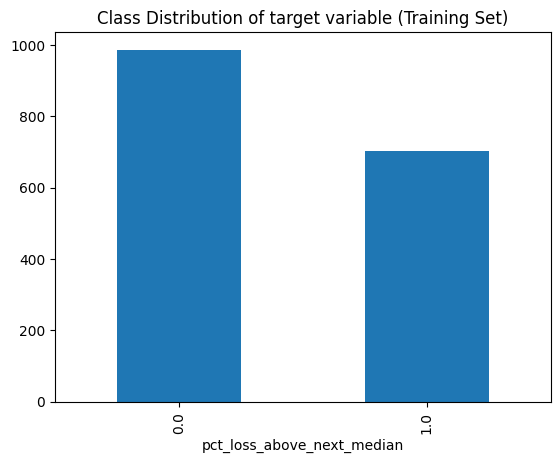

In [4]:
# train set target variable NaN and distribution check
print("Training Set Target Variable NaN Count:", train_df['pct_loss_above_next_median'].isna().sum())
print("Training Set Target Variable non NaN values:", train_df['pct_loss_above_next_median'].count())
print("Training Set Target Variable Distribution:\n", train_df['pct_loss_above_next_median'].value_counts())
train_df['pct_loss_above_next_median'].value_counts().plot(kind='bar', title='Class Distribution of target variable (Training Set)')


Test Set Target Variable NaN Count: 32
Test Set Target Variable non NaN values: 80
Test Set Target Variable Distribution:
 pct_loss_above_next_median
1.0    40
0.0    40
Name: count, dtype: int64


<Axes: title={'center': 'Class Distribution of target variable (Test Set)'}, xlabel='pct_loss_above_next_median'>

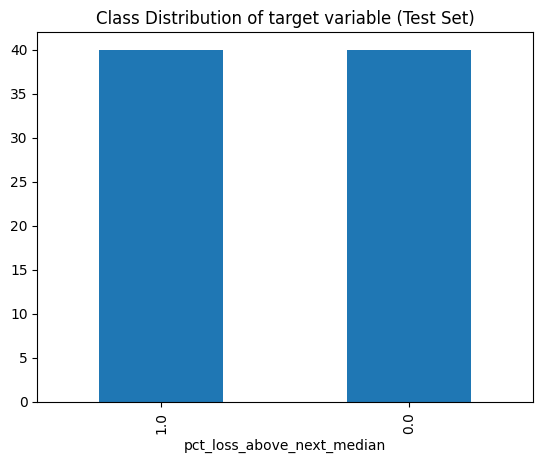

In [5]:
# test set target variable NaN and distribution check
print("Test Set Target Variable NaN Count:", test_df['pct_loss_above_next_median'].isna().sum())
print("Test Set Target Variable non NaN values:", test_df['pct_loss_above_next_median'].count())
print("Test Set Target Variable Distribution:\n", test_df['pct_loss_above_next_median'].value_counts())
test_df['pct_loss_above_next_median'].value_counts().plot(kind='bar', title='Class Distribution of target variable (Test Set)')

**Takeaways:** 
- The training and testing set still has some NaN values in the target variable due to unavailability of data of a particular state during the next quarter. We will only consider the rows whose target variable is non NaN during the training. The test set with NaN values in the target variable is still okay. 

- The distribution of the target variable is slightly imbalanced with more data in the low-risk category. This imbalance is one of the key reason to use better KPIs like F1 scores which gives an unbiased estimate of the model performance.

Moving on, initially we want to train our baseline model on just the weather features. Let us go ahead and drop the pathogen features. Additionally, our dataset contains certain categorical features such as year, quarter, state code and region code. We need to identify them to better represent them during our model training.  

In [5]:
TARGET_COLUMN = 'pct_loss_above_next_median'

# Removing rows with NaN target variable in training set
train_df = train_df.dropna(subset=[TARGET_COLUMN]).reset_index(drop=True)

# Defining feature sets for baseline model
WEATHER_FEATURES = [
    'M1_avg_prcp', 'M2_avg_prcp', 'M3_avg_prcp', 'M1_max_prcp', 'M2_max_prcp',
    'M3_max_prcp', 'Q_prcp_avg', 'Consecutive_Rain_Days', 'M1_avg_tmax',
    'M2_avg_tmax', 'M3_avg_tmax', 'M1_max_tmax', 'M2_max_tmax', 'M3_max_tmax',
    'Q_tmax_avg', 'Num_Heat_Stress_Days', 'M1_avg_tmin', 'M2_avg_tmin',
    'M3_avg_tmin', 'M1_min_tmin', 'M2_min_tmin', 'M3_min_tmin', 'Q_tmin_avg',
    'Num_Frost_Days', 'M1_avg_tvol', 'M2_avg_tvol', 'M3_avg_tvol',
    'M1_max_tvol', 'M2_max_tvol', 'M3_max_tvol', 'Q_tvol_avg',
    'Num_high_vol_days'
]

PATHOGEN_FEATURES = [
    'mean_varroa_q', 'mean_spores_q', 'abpv_prevalence_q', 'cbpv_prevalence_q', 
    'dwv_prevalence_q', 'iapv_prevalence_q', 'kbv_prevalence_q', 'lsv2_prevalence_q', 
    'varroa_total_samples_q', 'spores_total_samples_q', 'abpv_total_samples_q', 
    'cbpv_total_samples_q', 'dwv_total_samples_q', 'iapv_total_samples_q', 
    'kbv_total_samples_q', 'lsv2_total_samples_q', 'worst_month_mean_varroa', 
    'worst_month_mean_spores', 'worst_month_abpv_prevalence', 'worst_month_cbpv_prevalence', 
    'worst_month_dwv_prevalence', 'worst_month_iapv_prevalence', 'worst_month_kbv_prevalence', 
    'worst_month_lsv2_prevalence', 'last_month_mean_varroa', 'last_month_mean_spores', 
    'last_month_abpv_prevalence', 'last_month_cbpv_prevalence', 'last_month_dwv_prevalence', 
    'last_month_iapv_prevalence', 'last_month_kbv_prevalence', 'last_month_lsv2_prevalence'
]
# Categorical features in our dataset
CATEGORICAL_FEATURES = ['year','quarter','state_code','region']
BASELINE_FEATURES = CATEGORICAL_FEATURES + WEATHER_FEATURES
ALL_FEATURES = BASELINE_FEATURES + PATHOGEN_FEATURES

# Preparing training and testing data for baseline model
X_train_cv = train_df[BASELINE_FEATURES]
Y_train_cv = train_df[TARGET_COLUMN]

X_test_final = test_df[BASELINE_FEATURES]
Y_test_final = test_df[TARGET_COLUMN]

X_train_cv.head(10)

,year,quarter,state_code,region,M1_avg_prcp,M2_avg_prcp,M3_avg_prcp,M1_max_prcp,M2_max_prcp,M3_max_prcp,...,Q_tmin_avg,Num_Frost_Days,M1_avg_tvol,M2_avg_tvol,M3_avg_tvol,M1_max_tvol,M2_max_tvol,M3_max_tvol,Q_tvol_avg,Num_high_vol_days
0,2015,Q1,AL,Southeast,0.356189,0.278579,0.262464,0.378449,0.280944,0.122611,...,0.507617,0.430108,0.481383,0.625096,0.633761,0.256082,0.244946,0.340772,0.432035,0.085714
1,2015,Q1,AR,South,0.286879,0.218529,0.491522,0.337102,0.167917,0.280309,...,0.442194,0.548387,0.447237,0.552814,0.547126,0.131242,0.192033,0.238842,0.332830,0.028571
2,2015,Q1,AZ,NaN,0.146965,0.043040,0.068718,0.129187,0.059762,0.077435,...,0.520827,0.193548,0.541423,0.783124,0.827955,0.231114,0.498216,0.494572,0.645170,0.171429
3,2015,Q1,CA,West,0.053107,0.196454,0.047646,0.028858,0.290796,0.033634,...,0.563949,0.075269,0.456225,0.653648,0.765752,0.483995,0.538644,0.588661,0.507681,0.014286
4,2015,Q1,CO,Southwest,0.053559,0.092905,0.052546,0.027761,0.090292,0.036157,...,0.304711,0.892473,0.541171,0.706283,0.824415,0.325864,0.451249,0.532569,0.603675,0.157143
5,2015,Q1,CT,Northeast,0.285520,0.138436,0.187205,0.215256,0.133381,0.121847,...,0.206468,0.946237,0.336504,0.635159,0.572632,0.158771,0.234839,0.362485,0.340787,0.000000
6,2015,Q1,FL,Southeast,0.233190,0.221969,0.122736,0.187410,0.258858,0.092417,...,0.693655,0.043011,0.440916,0.621213,0.615672,0.288092,0.394174,0.404704,0.402558,0.000000
7,2015,Q1,GA,Southeast,0.299395,0.309105,0.172192,0.237280,0.404581,0.136906,...,0.525170,0.301075,0.464226,0.630831,0.655256,0.248399,0.280618,0.317250,0.439224,0.100000
8,2015,Q1,IA,Upper Midwest,0.042563,0.076409,0.034033,0.049785,0.196065,0.075294,...,0.215840,0.924731,0.337554,0.544425,0.734491,0.204225,0.287158,0.225573,0.382876,0.100000
9,2015,Q1,ID,Northwest,0.169443,0.127873,0.092323,0.088600,0.099711,0.053891,...,0.353188,0.849462,0.254751,0.534397,0.731773,0.225992,0.312128,0.514475,0.340184,0.014286


In [6]:
# Before we move on, let us make a final check on train and test set - No of features, No of data points etc. 
print("Training Set - No of features:", X_train_cv.shape[1])
print("Training Set - No of data points:", X_train_cv.shape[0])
print("Testing Set - No of features:", X_test_final.shape[1])
print("Testing Set - No of data points:", X_test_final.shape[0])
print("Features used for Baseline Model:\n", BASELINE_FEATURES)

Training Set - No of features: 36
Training Set - No of data points: 1691
Testing Set - No of features: 36
Testing Set - No of data points: 112
Features used for Baseline Model:
 ['year', 'quarter', 'state_code', 'region', 'M1_avg_prcp', 'M2_avg_prcp', 'M3_avg_prcp', 'M1_max_prcp', 'M2_max_prcp', 'M3_max_prcp', 'Q_prcp_avg', 'Consecutive_Rain_Days', 'M1_avg_tmax', 'M2_avg_tmax', 'M3_avg_tmax', 'M1_max_tmax', 'M2_max_tmax', 'M3_max_tmax', 'Q_tmax_avg', 'Num_Heat_Stress_Days', 'M1_avg_tmin', 'M2_avg_tmin', 'M3_avg_tmin', 'M1_min_tmin', 'M2_min_tmin', 'M3_min_tmin', 'Q_tmin_avg', 'Num_Frost_Days', 'M1_avg_tvol', 'M2_avg_tvol', 'M3_avg_tvol', 'M1_max_tvol', 'M2_max_tvol', 'M3_max_tvol', 'Q_tvol_avg', 'Num_high_vol_days']


#### Creating pipeline to avoid data leakage

Now that we have separated our training and testing set, let us proceed with encoding our categorical features. One way to encode them for our model is through one-hot encoding scheme which would create new features based on the exisiting categorical feature. For example, the quarter feature would be encoded into four new columns (Q1, Q2, Q3, Q4). A row that was originally 'Q1' would be represented as [1, 0, 0, 0] across these new columns, while a 'Q2' row would be [0, 1, 0, 0].

Caution: One has to be very careful not to create data leakage when using the one-hot encoding scheme. For instance, if we apply this scheme on our entire training set and then proceed to create validation time series split, there could be potential data leakage from the later years to the initial folds consisting of initial years. To elaborate with an illustrative example, suppose our first fold consists of training set from 2015-16 and validation set from 2017. Consider a case where the Hawaii data exists only from 2017. If we directly use one-hot encoding scheme, there would be a column in the training set with state_Hawaii set to [0,...0]. Our model built using 2015-2016 data is already trained expecting Hawaii state feature which we want to avoid. 

Pipeline from scikit-learn is a nice module that strictly enforces splitting before the model training and makes our lives easier. We will be using this feature below.

In [7]:
# We use OneHotEncoder and tell it to ignore unknown categories
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Create a preprocessor that applies transformers to the correct columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, CATEGORICAL_FEATURES),
        # We tell it to leave all other features (our weather data) alone
        ('num', 'passthrough', WEATHER_FEATURES)
    ],
    remainder='passthrough' # Keep any other columns
)

# We use LGBMClassifier for our binary classification task
model = lgb.LGBMClassifier(random_state=42, n_jobs=-1)

# Create the full pipeline - First preprocesses the data, then feeds it to the model
baseline_pipeline = Pipeline(steps=[('preprocessor', preprocessor),('model', model)])

# Defining cross-validation strategy
tscv = TimeSeriesSplit(n_splits=5)

Now that we have defined our pipeline for handling preprocessing and initiated our lightgbm model for classification, let us proceed with defining KPIs for evaluating our model's performance. Fianlly, let us also run the cross-validation.

In [8]:
# Define the scorers for our KPIs
# We must use make_scorer for metrics that need specific parameters (like pos_label - positive class)
scorers = {'f1_score': make_scorer(f1_score, pos_label=1),'roc_auc': make_scorer(roc_auc_score)}

print("Running 5-fold Time-Series Cross-Validation...")

# Run the cross-validation
cv_results = cross_validate( baseline_pipeline, X_train_cv, Y_train_cv, cv=tscv, scoring=scorers, n_jobs=-1, verbose=1)

# Print the average and standard deviation of the scores
print("\n--- Cross-Validation Results ---")
print(f"Average F1 Score:   {np.mean(cv_results['test_f1_score']):.3f} +/- {np.std(cv_results['test_f1_score']):.3f}")
print(f"Average ROC-AUC Score: {np.mean(cv_results['test_roc_auc']):.3f} +/- {np.std(cv_results['test_roc_auc']):.3f}")
print("\nIndividual Fold Scores:")
print(f"F1:   {cv_results['test_f1_score']}")
print(f"ROC-AUC: {cv_results['test_roc_auc']}")


Running 5-fold Time-Series Cross-Validation...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[LightGBM] [Info] Number of positive: 400, number of negative: 448[LightGBM] [Info] Number of positive: 603, number of negative: 807

[LightGBM] [Info] Number of positive: 140, number of negative: 146[LightGBM] [Info] Number of positive: 272, number of negative: 295[LightGBM] [Info] Number of positive: 508, number of negative: 621


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000859 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001227 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000959 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2801
[LightGBM] [Info] Total Bins 5481
[LightGBM] [Info] Total Bins 7327
[LightGBM] [I

/opt/homebrew/Caskroom/miniforge/base/envs/d2l/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/opt/homebrew/Caskroom/miniforge/base/envs/d2l/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    2.6s remaining:    3.9s


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

--- Cross-Validation Results ---
Average F1 Score:   0.454 +/- 0.066
Average ROC-AUC Score: 0.546 +/- 0.043

Individual Fold Scores:
F1:   [0.56170213 0.49264706 0.39631336 0.43835616 0.38297872]
ROC-AUC: [0.62583893 0.51008476 0.50832263 0.5483305  0.53655116]


/opt/homebrew/Caskroom/miniforge/base/envs/d2l/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/d2l/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/d2l/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.0s finished


**Takeaways:** The baseline model scores are pretty low which indicated the model might by underfitting. There are two paths that we could take from here. Try to optimize the baseline model by hyperparameter tuning or hypothesize that we also need the varroa and pathogen data to have a stronger predictive signal. If we see any improvements by just including these additional features, that is great! We could further optimize the hyperparameters by GridSearchCV/
RandomizedSearchCV. 